# LSA - News Classification

Project 1 - Linear Algebra (Spring 1403) - Dr. Sarafraz

ECE - University of Tehran

Designed by:
[Erfan Asgari](https://github.com/erfanasgari21),
[Fardin Abbasi](https://github.com/fardinabbasi)

<div dir="rtl">

# سوالات مفهومی

</dic>

## Q1

Term Frequency (TF) measures how often a term $t$ occurs in a document $d$, usually normalized by document length:

$$TF(t, d) = \frac{\text{count}(t, d)}{\sum_{t' \in d} \text{count}(t', d)}$$

Inverse Document Frequency (IDF) measures how rare a term is across the whole corpus $D$:

$$IDF(t, D) = \log \frac{|D|}{|\{d \in D : t \in d\}|}$$

Why each is misleading on its own:
- TF alone overweights words that are simply common in every document (like the). high TF, but zero topical signal.
- IDF alone overweights words that are rare for uninteresting reasons (like typos). high IDF, but not representative of a document's actual topic.
- TF-IDF = TF × IDF keeps only words that are frequent within a document but not frequent across the whole corpus like words that are actually distinctive of that document's content. This is why the two signals must be combined rather than studied independently.

## Q2


When truncating an SVD to rank $k$, we want to keep the singular values that carry real signal and discard the tail that mostly reflects noise. Plotting the singular values in decreasing order (the scree plot) typically shows a steep drop followed by a long, flat tail. The elbow point is where the curve bends from steep to flat — past that point, each additional component buys very little extra explained variance.

A reproducible way to find it (rather than eyeballing it) is to measure, for every point on the curve, its perpendicular distance to the straight line connecting the first and last point, and pick the point of maximum distance as the elbow. That is exactly what find_elbow does further below.

## Q3

To check how good the rank-$k$ approximation is, we compare $A_k$ to the original $A$ using the Frobenius norm of their difference:

$$\text{Error} = \Vert{}A - A_k\Vert{}_F = \sqrt{\sum_{i,j} (A_{ij} - (A_k)_{ij})^2}$$

we don't actually need to build $A_k$ to get this number though. it turns out this error is just the square root of the sum of the squared singular values you dropped (everything after rank $k$):

$$\Vert{}A - A_k\Vert{}_F = \sqrt{\sigma_{k+1}^2 + \sigma_{k+2}^2 + \dots + \sigma_r^2}$$

So the bigger the singular values you cut off, the bigger the error. To make this comparable across different matrices, divide by the norm of the original matrix to get a relative error:

$$\text{Error}_{\text{rel}} = \frac{\Vert{}A - A_k\Vert{}_F}{\Vert{}A\Vert{}_F}$$

## Q4

Cosine similarity measures the angle between two vectors:

$$\cos(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \, \|\mathbf{v}\|}$$

- Range $[-1, 1]$.
- $1$ = same direction (very similar)
- $0$ = unrelated
- $-1$ = opposite direction.
- Also it is scale invariant, which makes it good for comparing words regardless of length or frequency scale.

Euclidean distance measures straight-line distance:

$$d(\mathbf{u}, \mathbf{v}) = \|\mathbf{u} - \mathbf{v}\|_2 = \sqrt{\sum_i (u_i - v_i)^2}$$

- Range $[0, \infty)$.
- $0$ = identical vectors
- larger values mean farther apart
- but its Sensitive to magnitude. two vectors that point in the same direction but differ in scale will still have nonzero (possibly large) distance.

## Q5


Z-score standardization rescales each feature (column) $j$ to zero mean and unit variance:

$$x'_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

SVD finds directions of maximum variance in the data. Without standardization, words that simply occur more often on average (high raw variance) would dominate the singular vectors purely because of their scale, not because they are semantically important.
Standardizing first puts every word on equal footing so the discovered concepts reflect co-occurrence patterns rather than raw frequency magnitude. this is why we standardize the Bag-of-Words matrix before decomposing it.

## Q6


For a large matrix $A \in \mathbb{R}^{m \times n}$, exact SVD costs $\mathcal{O}(mn\min(m,n))$, which becomes impractical at scale. 
Randomized SVD instead approximates the range of $A$ using random projections, then performs an exact SVD on a much smaller matrix.

Pseudocode (target rank $k$, power iterations $q$):
1. Draw a random Gaussian matrix $\Omega \in \mathbb{R}^{n \times k}$.
2. Form the sample matrix $Y = A\Omega$.
3. *(Optional, improves accuracy when the spectrum decays slowly)* for $q$ iterations: $Y = A(A^T Y)$.
4. Orthonormalize $Y$ via QR decomposition: $Q, R = \text{qr}(Y)$.
5. Project $A$ onto the low-dimensional subspace: $B = Q^T A$ (shape $k \times n$).
6. Compute the exact SVD of the small matrix $B$: $U_B, S, V^T = \text{svd}(B)$.
7. Map back to the original space: $U = Q U_B$.
8. Return $U, S, V^T$.

This is cheap because steps 1–3 only require matrix-vector products, and the only real SVD is on a $k \times n$ matrix instead of the full $m \times n$ matrix. It is the method of choice whenever $A$ is too large for exact SVD, or when only a low rank approximation is needed.

In [1]:
!pip install kaggle



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Download the Dataset

In [2]:
import os
os.environ['KAGGLE_USERNAME'] = ''
os.environ['KAGGLE_KEY'] = ''
!kaggle datasets download -d tanishqdublish/text-classification-documentation

Dataset URL: https://www.kaggle.com/datasets/tanishqdublish/text-classification-documentation
License(s): apache-2.0


text-classification-documentation.zip: Skipping, found more recently modified local copy (use --force to force download)


In [67]:
import zipfile

if os.path.exists('text-classification-documentation.zip'):
    with zipfile.ZipFile('text-classification-documentation.zip', 'r') as zip_ref:
        zip_ref.extractall('text_classification')
    print('Dataset extracted successfully.')
else:
    print('Zip file not found. Skipping extraction since local dataset exists.')


Dataset extracted successfully.


In [68]:
import pandas as pd

if os.path.exists('dataset/df_file.csv'):
    file_path = 'dataset/df_file.csv'
elif os.path.exists('text_classification/df_file.csv'):
    file_path = 'text_classification/df_file.csv'
else:
    file_path = 'df_file.csv'
df = pd.read_csv(file_path)
print('Dataset loaded successfully, shape:', df.shape)


Dataset loaded successfully, shape: (2225, 2)


## Q7. Preprocessing

In [69]:
import re

def cleanse_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

df['Text'] = df['Text'].apply(cleanse_text)

## Visualization

### Table Summary

In [70]:
df.head()

,Text,Label
0,budget to set scene for election gordon brown ...,0
1,army chiefs in regiments decision military chi...,0
2,howard denies split over id cards michael howa...,0
3,observers to monitor uk election ministers wil...,0
4,kilroy names election seat target exchat show ...,0


### Labels Frequency

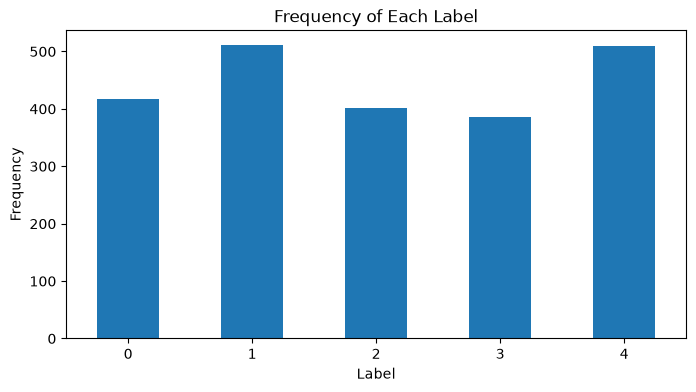

In [71]:
import matplotlib.pyplot as plt

label_frequency = df['Label'].value_counts()

plt.figure(figsize=(8, 4))
label_frequency.sort_index().plot(kind='bar')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('Frequency of Each Label')
plt.xticks(rotation=0)
plt.show()


## Q8.

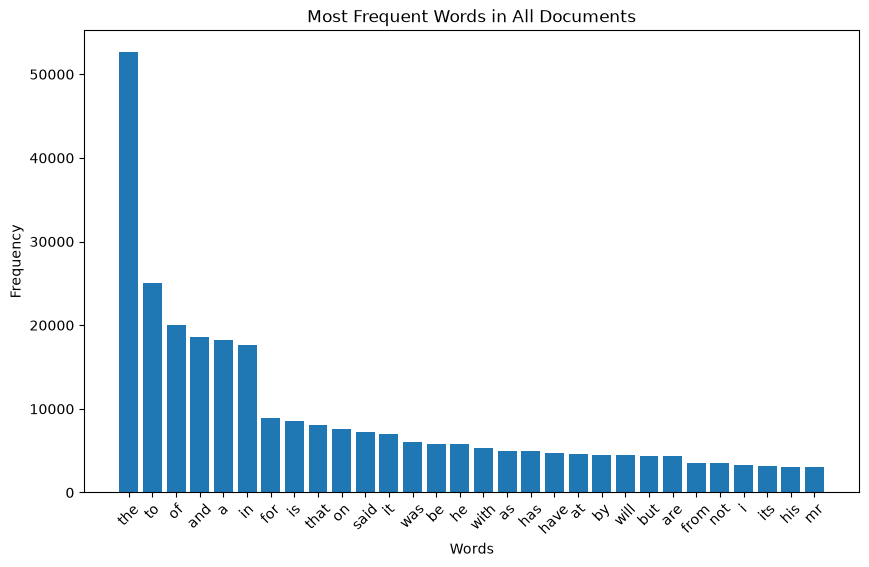

In [72]:
from collections import Counter
import string


all_text = " ".join(df['Text'])

all_text = all_text.lower()
all_text = re.sub(f"[{string.punctuation}]", " ", all_text)
words = all_text.split()

word_counts = Counter(words)

most_common_words = word_counts.most_common(30)

words, counts = zip(*most_common_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Most Frequent Words in All Documents')
plt.xticks(rotation=45)
plt.show()


> the 30 most frequent words are almost all generic ("the", "said", "year", "also", "mr") words that can show up in every topic.
Raw frequency alone does not tell us what a document is about.
This is exactly the TF vs. TF-IDF problem from Q1: to find topic
signal we need words that are frequent in a document but not frequent
everywhere, which is why the words.csv vocabulary matters more than raw counts.

### Word Cloud

In [9]:
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Q9. Word Cloud

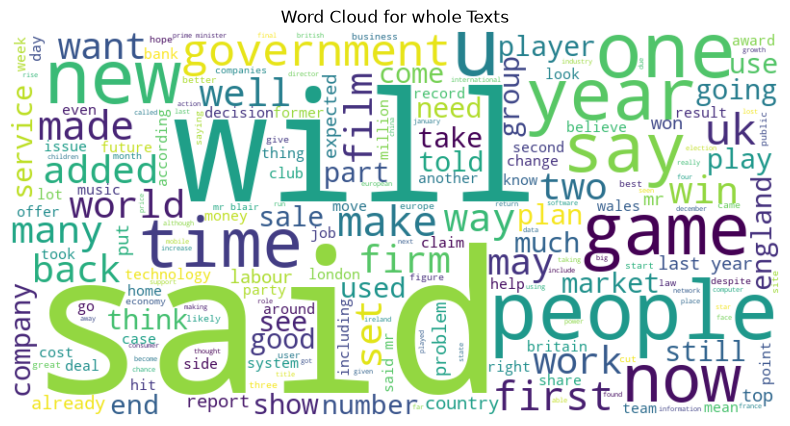

In [73]:
from wordcloud import WordCloud


def generate_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

text = " ".join(df['Text'])
generate_word_cloud(text, f'Word Cloud for whole Texts')

> How to read word clouds:

>each word font size is multiplied by its frequency in the underlyin text.
Word selection typically doesnt use stopwords first
colors are usually just for showing and vizualize and dont have special meaning.
Word clouds are good for a quick look at
dominant themes and words.

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer
documents = df['Text'].str.lower().str.replace(f"[{string.punctuation}]", " ", regex=True)

vectorizer = TfidfVectorizer(stop_words='english', max_features=150)
X = vectorizer.fit_transform(documents)

feature_names = vectorizer.get_feature_names_out()

feature_names

array(['10', '2003', '2004', '2005', 'according', 'action', 'added',
       'bank', 'bbc', 'best', 'better', 'big', 'blair', 'britain',
       'british', 'brown', 'business', 'came', 'campaign', 'chief',
       'club', 'come', 'companies', 'company', 'country', 'court', 'data',
       'day', 'deal', 'decision', 'despite', 'did', 'digital', 'director',
       'dont', 'economic', 'economy', 'election', 'end', 'england',
       'europe', 'european', 'expected', 'far', 'figures', 'film',
       'final', 'firm', 'firms', 'future', 'game', 'games', 'general',
       'going', 'good', 'got', 'government', 'great', 'group', 'growth',
       'help', 'high', 'hit', 'home', 'howard', 'im', 'including',
       'industry', 'information', 'international', 'just', 'know',
       'labour', 'law', 'life', 'like', 'likely', 'london', 'make',
       'market', 'media', 'million', 'minister', 'mobile', 'money',
       'month', 'months', 'mr', 'music', 'need', 'net', 'new', 'news',
       'number', 'office',

In [75]:
important_words = pd.read_csv("words.csv").squeeze().tolist()

## Q10

## Bag of Words

In [76]:
def count_words(text):
    word_count = {word: 0 for word in important_words}
    for word in text.split():
        if word in word_count:
            word_count[word] += 1
    return word_count

df['Word_Counts'] = df['Text'].apply(count_words)
word_counts_df_all = pd.DataFrame(df['Word_Counts'].tolist(), index=df.index)

df_train = df.iloc[:2000].reset_index(drop=True)
df_test = df.iloc[2000:].reset_index(drop=True)

word_counts_df = word_counts_df_all.iloc[:2000].reset_index(drop=True)
word_counts_df_test = word_counts_df_all.iloc[2000:].reset_index(drop=True)

print('Training BoW matrix shape:', word_counts_df.shape)
print('Test BoW matrix shape:', word_counts_df_test.shape)
word_counts_df

Training BoW matrix shape: (2000, 52)
Test BoW matrix shape: (225, 52)


,artist,chief,china,club,company,computer,country,deal,digital,director,...,sale,service,tax,technology,time,uk,user,win,won,work
0,0,1,0,0,0,0,0,0,0,0,...,0,0,6,0,2,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,3,0,0,0,1
4,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,3,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,1,0,0,2,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1996,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1997,0,2,0,0,1,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [77]:
word_counts_df.describe()

,artist,chief,china,club,company,computer,country,deal,digital,director,...,sale,service,tax,technology,time,uk,user,win,won,work
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.026500,0.168500,0.079500,0.152000,0.229500,0.156000,0.172500,0.180000,0.207000,0.199000,...,0.096500,0.214500,0.181000,0.269000,0.544500,0.446000,0.026500,0.302500,0.261500,0.285000
std,0.220957,0.499232,0.659088,0.788167,0.696471,0.710575,0.611499,0.691259,0.989263,0.701887,...,0.469359,0.838356,1.075554,1.054607,1.031286,1.112521,0.220957,0.863925,0.804637,0.766204
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,7.000000,13.000000,12.000000,7.000000,8.000000,8.000000,8.000000,17.000000,19.000000,...,7.000000,13.000000,14.000000,12.000000,20.000000,12.000000,4.000000,13.000000,12.000000,15.000000


## Standardization

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
word_counts_scaled = scaler.fit_transform(word_counts_df)

## Q11

In [80]:
import numpy as np

U_full, S_full, Vt_full = np.linalg.svd(word_counts_scaled, full_matrices=False)

print('Full SVD shapes (Q11):')
print(' U shape :', U_full.shape)
print(' S shape :', S_full.shape, '(diagonal of Sigma, stored as a vector)')
print(' Vt shape:', Vt_full.shape)

Full SVD shapes (Q11):
 U shape : (2000, 52)
 S shape : (52,) (diagonal of Sigma, stored as a vector)
 Vt shape: (52, 52)


## Q12

In [81]:
def find_elbow(values):
    n = len(values)
    x = np.arange(1, n + 1, dtype=float)
    y = np.asarray(values, dtype=float)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    line_vec = (p2 - p1) / np.linalg.norm(p2 - p1)
    distances = []
    for xi, yi in zip(x, y):
        p = np.array([xi, yi])
        proj = p1 + np.dot(p - p1, line_vec) * line_vec
        distances.append(np.linalg.norm(p - proj))
    return int(np.argmax(distances)) + 1

In [82]:
total_variance = np.sum(S_full**2)
explained_variance_ratio = (S_full**2) / total_variance
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

n_components = find_elbow(S_full)
print(f'Elbow point: k = {n_components}')

Elbow point: k = 11


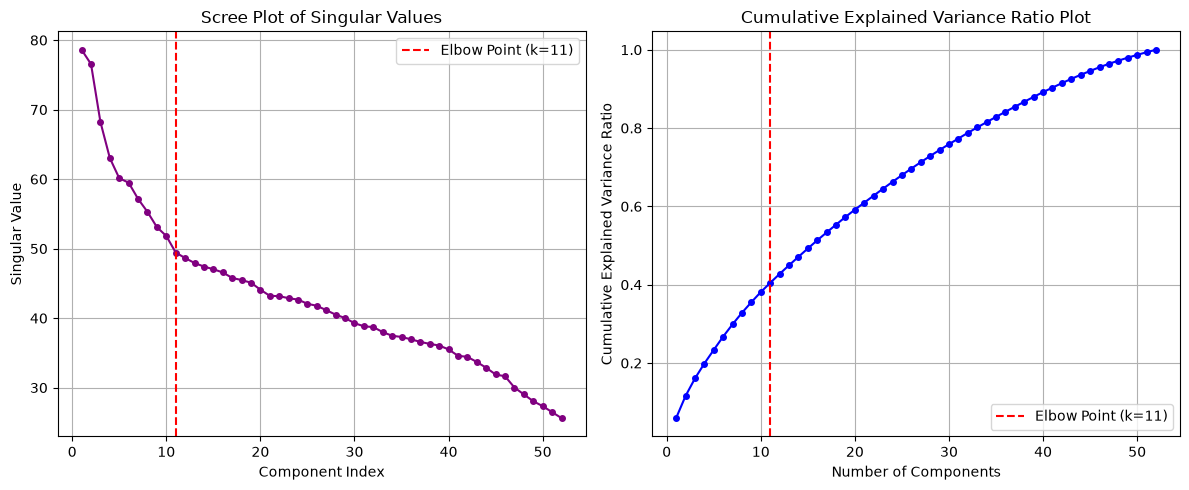

In [83]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(S_full) + 1), S_full, 'o-', color='purple', markersize=4)
plt.axvline(x=n_components, color='red', linestyle='--', label=f'Elbow Point (k={n_components})')
plt.xlabel('Component Index')
plt.ylabel('Singular Value')
plt.title('Scree Plot of Singular Values')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, 'o-', color='blue', markersize=4)
plt.axvline(x=n_components, color='red', linestyle='--', label=f'Elbow Point (k={n_components})')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio Plot')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

> the singular values decay gradually rather than showing one sharp knee (52 fairly independent curated words, spread across 5 topics, don't collapse onto a handful of dominant directions). The distance to chord rule above still gives a principled, reproducible choice of k rather than an arbitrarily handpicked number.

In [84]:
U_k = U_full[:, :n_components]
S_k = np.diag(S_full[:n_components])
Vt_k = Vt_full[:n_components, :]

lsi_matrix = U_k @ S_k

class _TruncatedSVDResult:
    def __init__(self, components):
        self.components_ = components

svd = _TruncatedSVDResult(Vt_k)

X_reconstructed = U_k @ S_k @ Vt_k
reconstruction_error_abs = np.linalg.norm(word_counts_scaled - X_reconstructed, 'fro')
reconstruction_error_rel = reconstruction_error_abs / np.linalg.norm(word_counts_scaled, 'fro')

print('Truncated SVD details:')
print(f' Selected rank (k): {n_components}')
print(f' Absolute reconstruction error (Frobenius Norm): {reconstruction_error_abs:.4f}')
print(f' Relative reconstruction error: {reconstruction_error_rel:.4f}')


Truncated SVD details:
 Selected rank (k): 11
 Absolute reconstruction error (Frobenius Norm): 248.8014
 Relative reconstruction error: 0.7715


## Randomized SVD Implementation (Q13 & Q14)


## Q13. Implement Randomized SVD

In [85]:
def randomized_svd(A, rank, n_iter=5):
    m, n = A.shape
    # Step 1: Generate a random Gaussian projection matrix
    omega = np.random.randn(n, rank)

    # Step 2: Form a sample matrix Y = A * omega
    Y = A @ omega

    # Power iterations to improve singular vector accuracy
    for _ in range(n_iter):
        Y = A @ (A.T @ Y)

    # Step 3: Orthonormalize Y using QR decomposition to find an orthonormal basis Q
    Q, _ = np.linalg.qr(Y)

    # Step 4: Project A onto the low-dimensional subspace: B = Q.T @ A
    B = Q.T @ A

    # Step 5: Compute SVD on the smaller matrix B
    Ub, S, Vt = np.linalg.svd(B, full_matrices=False)

    # Step 6: Reconstruct the left singular vectors of A
    U = Q @ Ub

    return U, S, Vt


## Q14. Run Randomized SVD and Compare

In [86]:
U_rand, S_rand, Vt_rand = randomized_svd(word_counts_scaled, n_components)

X_reconstructed_rand = U_rand @ np.diag(S_rand) @ Vt_rand
reconstruction_error_rand_abs = np.linalg.norm(word_counts_scaled - X_reconstructed_rand, 'fro')
reconstruction_error_rand_rel = reconstruction_error_rand_abs / np.linalg.norm(word_counts_scaled, 'fro')

print(f"Randomized SVD with rank k = {n_components}:")
print(f"  Absolute reconstruction error: {reconstruction_error_rand_abs:.4f}")
print(f"  Relative reconstruction error: {reconstruction_error_rand_rel:.4f}")

print(f"\nReconstruction Error Comparison (k = {n_components}):")
print(f"  Truncated SVD:  {reconstruction_error_rel:.4f}")
print(f"  Randomized SVD: {reconstruction_error_rand_rel:.4f}")


Randomized SVD with rank k = 11:
  Absolute reconstruction error: 251.3082
  Relative reconstruction error: 0.7793

Reconstruction Error Comparison (k = 11):
  Truncated SVD:  0.7715
  Randomized SVD: 0.7793


**Q14:** Randomized SVD gets a reconstruction error very close to the deterministic Truncated SVD, at a lower the cost because  it never computes a full O(mn min(m,n)) decomposition, but only a handful of matrix vector products plus one exact SVD on a small k x n matrix. 
If corpus were the size of the whole internet text, exact SVD would be very computationally bad. so Randomized SVD is preferred. because it scales roughly linearly in matrix size and works well with sparse matrices, trading a small amount of accuracy for a good reduction in compute andmemory cost.

## Visualize Word Embeddings

In [87]:
import seaborn as sns

def plot_heatmap(data, title , figsize , xlabel , ylabel):
    plt.figure(figsize=figsize)
    sns.heatmap(data, annot=True, cmap='viridis', fmt='.3f')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

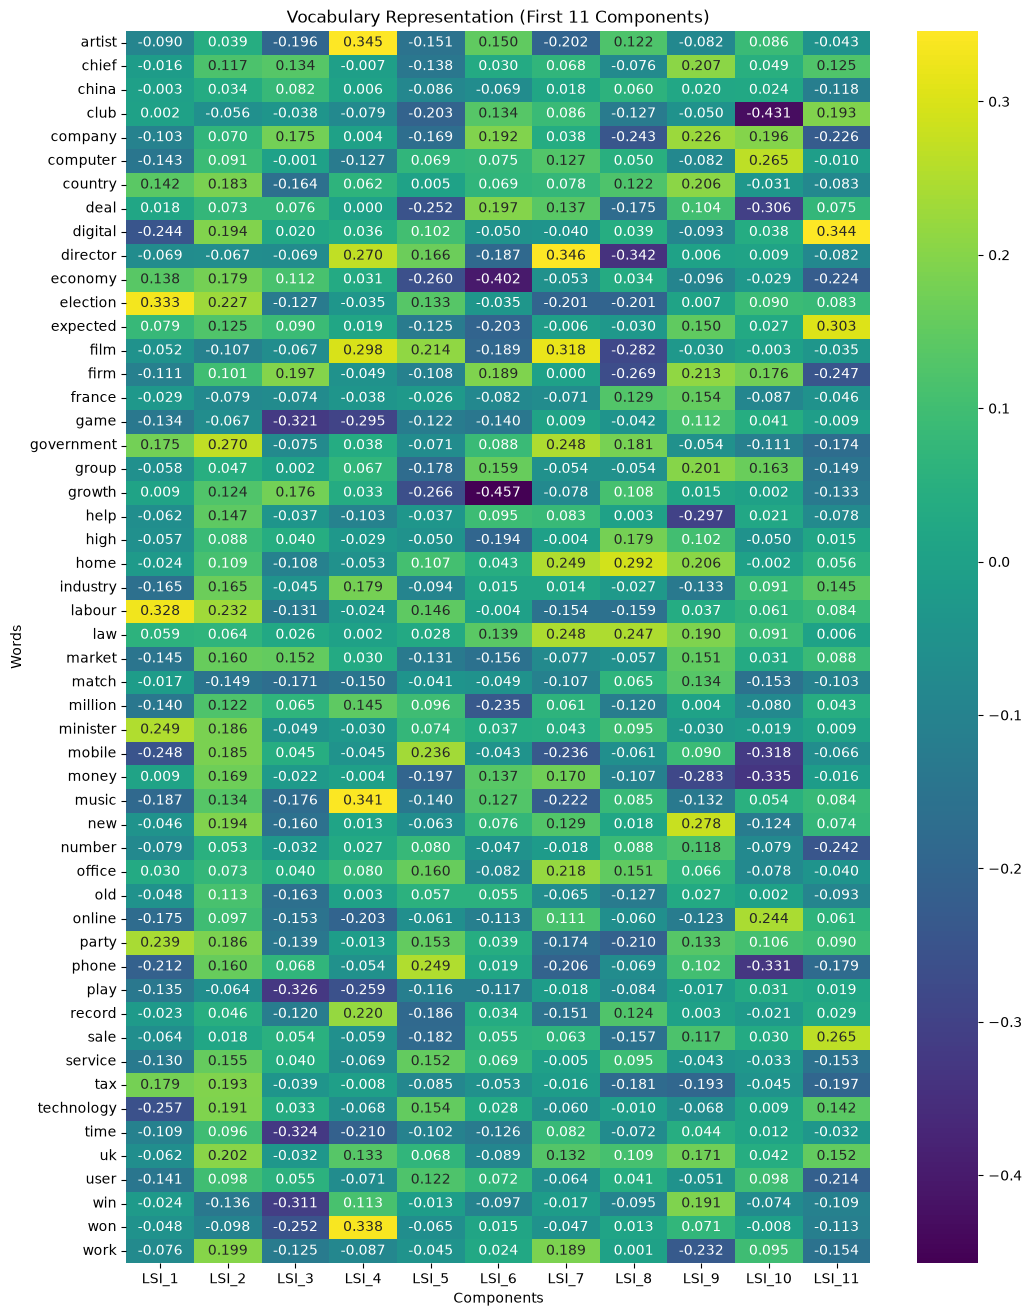

In [88]:
lsi_df = pd.DataFrame(lsi_matrix, columns=[f'LSI_{i+1}' for i in range(n_components)])
lsi_df['Label'] = df_train['Label']

vocab_representation = svd.components_.T

vocab_df_7 = pd.DataFrame(vocab_representation[:, :n_components], index=important_words, columns=[f'LSI_{i+1}' for i in range(n_components)])

plot_heatmap(vocab_df_7, f'Vocabulary Representation (First {n_components} Components)', (12, 16) , 'Components','Words')

## Q15

## Intuition of each component (concept)

In [89]:
top_words = {}
for i in range(n_components):
    component_loadings = vocab_representation[:, i]
    top_indices = abs(component_loadings).argsort()[-5:][::-1]
    top_words[f'Component_{i+1}'] = [(important_words[idx], component_loadings[idx]) for idx in top_indices]


for component, words in top_words.items():
    print(f"{component}:")
    for word, value in words:
        print(f"  {word}: {value:.4f}")


Component_1:
  election: 0.3332
  labour: 0.3281
  technology: -0.2570
  minister: 0.2487
  mobile: -0.2478
Component_2:
  government: 0.2701
  labour: 0.2317
  election: 0.2273
  uk: 0.2019
  work: 0.1994
Component_3:
  play: -0.3262
  time: -0.3245
  game: -0.3207
  win: -0.3106
  won: -0.2521
Component_4:
  artist: 0.3450
  music: 0.3412
  won: 0.3378
  film: 0.2977
  game: -0.2952
Component_5:
  growth: -0.2655
  economy: -0.2604
  deal: -0.2522
  phone: 0.2493
  mobile: 0.2360
Component_6:
  growth: -0.4572
  economy: -0.4017
  million: -0.2351
  expected: -0.2030
  deal: 0.1975
Component_7:
  director: 0.3459
  film: 0.3181
  home: 0.2493
  government: 0.2482
  law: 0.2476
Component_8:
  director: -0.3420
  home: 0.2919
  film: -0.2823
  firm: -0.2692
  law: 0.2472
Component_9:
  help: -0.2973
  money: -0.2832
  new: 0.2784
  work: -0.2318
  company: 0.2260
Component_10:
  club: -0.4314
  money: -0.3346
  phone: -0.3306
  mobile: -0.3185
  deal: -0.3062
Component_11:
  digital: 0

> **Interpretation Q15:** looking at the printed top 5 words, several components map onto recognizable topics. a component dominated by "play, game, win, won" reads as Sport, one dominated by artist, music, film, director reads as Entertainment, one dominated by "growth, economy, million" reads as Business, and one dominated by "election, labour, minister, government" reads as Politics. 
This kind of manual labeling is a useful sanity check, but as Q19 below notes, it doesn't scale. we don't want to eyeball every component by hand in general.

## Q16

In [90]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

def word_similarity(word1, word2, important_words):
    if word1 not in important_words or word2 not in important_words:
        return None
    word1_index = important_words.index(word1)
    word2_index = important_words.index(word2)

    word1_representation = svd.components_.T[word1_index]
    word2_representation = svd.components_.T[word2_index]

    cosine_sim = cosine_similarity([word1_representation], [word2_representation])[0][0]
    euclidean_dist = euclidean_distances([word1_representation], [word2_representation])[0][0]

    return {'cosine_similarity': cosine_sim, 'euclidean_distance': euclidean_dist}

word_pairs = [
    ('mobile', 'technology'),
    ('director', 'film'),
    ('win', 'won'),
    ('play', 'game'),
    ('play', 'law'),
    ('government', 'music')
]


for w1, w2 in word_pairs:
    sims = word_similarity(w1, w2, important_words)
    print(f'({w1}, {w2}):')
    print(f"  Cosine Similarity:  {sims['cosine_similarity']:.4f}")
    print(f"  Euclidean Distance: {sims['euclidean_distance']:.4f}")


(mobile, technology):
  Cosine Similarity:  0.5843
  Euclidean Distance: 0.4712
(director, film):
  Cosine Similarity:  0.9833
  Euclidean Distance: 0.1141
(win, won):
  Cosine Similarity:  0.7535
  Euclidean Distance: 0.3201
(play, game):
  Cosine Similarity:  0.9574
  Euclidean Distance: 0.1485
(play, law):
  Cosine Similarity:  -0.3098
  Euclidean Distance: 0.7474
(government, music):
  Cosine Similarity:  -0.0079
  Euclidean Distance: 0.7665


**Interpretation (Q16):** semantically related pairs that tend to co occur in the same topic (director/film, play/game, win/won) show high cosine similarity and low Euclidean distance. Unrelated cross topic pairs (play/law, government/music) show low cosine similarity and larger Euclidean distance. the latent space is picking up on topical association, something raw word co occurrence counts alone would not directly give.

## Q17

## Similarity between documents and words

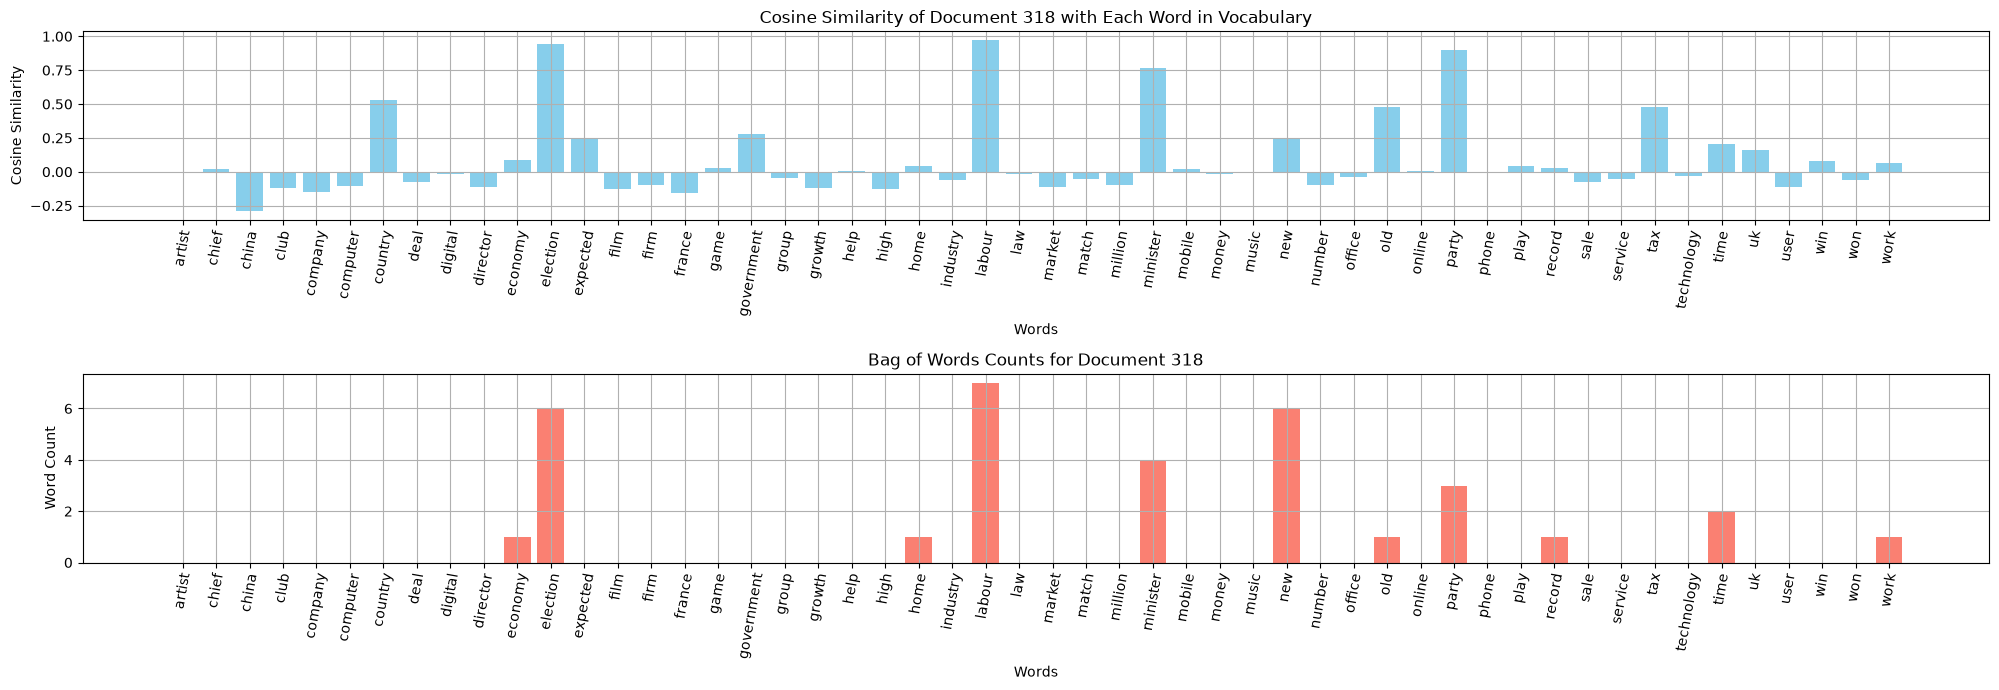

In [91]:
import matplotlib.pyplot as plt

def document_similarity_with_words(doc_index, df, important_words):
    doc_representation = lsi_matrix[doc_index]

    word_similarities = {}
    for word in important_words:
        word_index = important_words.index(word)
        word_representation = svd.components_.T[word_index]
        similarity = cosine_similarity([doc_representation], [word_representation])[0][0]
        word_similarities[word] = similarity

    return word_similarities


STUDENT_ID_LAST3 = 318
doc_index = STUDENT_ID_LAST3 % len(lsi_matrix)
similarities = document_similarity_with_words(doc_index, lsi_df.drop(columns=['Label']), important_words)

words = list(similarities.keys())
cosine_sim_values = list(similarities.values())
word_counts = df_train['Word_Counts'].iloc[doc_index]

plt.figure(figsize=(20, 7))

plt.subplot(2, 1, 1)
plt.bar(words, cosine_sim_values, color='skyblue')
plt.xlabel('Words')
plt.ylabel('Cosine Similarity')
plt.title(f'Cosine Similarity of Document {doc_index} with Each Word in Vocabulary')
plt.xticks(rotation=80)
plt.grid(True)

plt.subplot(2, 1, 2)
plt.bar(word_counts.keys(), word_counts.values(), color='salmon')
plt.xlabel('Words')
plt.ylabel('Word Count')
plt.title(f'Bag of Words Counts for Document {doc_index}')
plt.xticks(rotation=80)
plt.grid(True)

plt.tight_layout()
plt.show()


**Comparison (Q17):** the raw word-count chart is mostly zero, while the cosine-similarity chart is dense and every word gets a nonzero latent-space similarity, including words the document never uses verbatim but that are semantically close to words it does use.

# Querying
To find the most relevant documents to a single word.

In [92]:
from sklearn.metrics.pairwise import cosine_similarity

def find_relevant_documents(word, df, important_words):
    if word not in important_words:
        print(f"The word '{word}' is not in the vocabulary.")
        return None

    word_index = important_words.index(word)
    word_representation = svd.components_.T[word_index]

    cosine_similarities = cosine_similarity([word_representation], df)
    cosine_similarities = cosine_similarities.flatten()

    result_df = pd.DataFrame({'Document_Index': df.index, 'Cosine_Similarity': cosine_similarities})
    result_df = result_df.sort_values(by='Cosine_Similarity', ascending=False)
    relevant_indices = result_df['Document_Index'].tolist()

    return relevant_indices, cosine_similarities

word = 'game'
relevant_indices, _ = find_relevant_documents(word, lsi_df.drop(columns=['Label']), important_words)

relevant_texts = df_train.loc[relevant_indices[:10]]
relevant_texts

,Text,Label,Word_Counts
1086,blinx sequel purrs nicely the original blinx w...,2,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
695,moody joins up with england lewis moody has fl...,1,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
945,halo fans hope for sequel xbox video game halo...,2,"{'artist': 0, 'chief': 1, 'china': 0, 'club': ..."
1094,ban hits halflife 2 pirates hard about 20000 p...,2,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
606,real will finish abandoned match real madrid a...,1,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
929,bond game fails to shake or stir for gaming fa...,2,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
956,no half measures with halflife 2 could halflif...,2,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
486,wenger steps up row arsene wenger has stepped ...,1,"{'artist': 0, 'chief': 1, 'china': 0, 'club': ..."
1232,gritty return for prince of persia still baski...,2,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
1143,football manager scores big time for the past ...,2,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."


## Similarity between words and labels

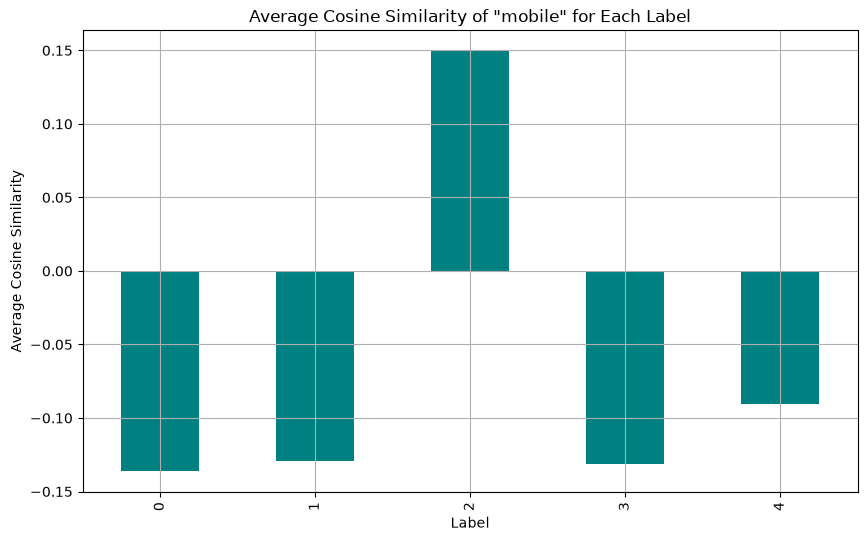

In [93]:
word = 'mobile'
relevant_indices, cosine_similarities = find_relevant_documents(word, lsi_df.drop(columns=['Label']), important_words)

df_train['Cosine_Similarity'] = cosine_similarities

average_cosine_similarity_per_label = df_train.groupby('Label')['Cosine_Similarity'].mean()

plt.figure(figsize=(10, 6))
average_cosine_similarity_per_label.plot(kind='bar', color='teal')
plt.title(f'Average Cosine Similarity of "{word}" for Each Label')
plt.xlabel('Label')
plt.ylabel('Average Cosine Similarity')
plt.grid(True)
plt.show()


## Q18

**Discussion (Q18):** a document about phones that uses mobile and digital but never says technology would score zero overlap with a raw BoW query for technology. exact keyword search would simply miss. In the latent space, mobile, digital and technology end up close together because they tend to apper with each other across documents (see the mobile example above, and the (mobile, technology) similarity computed above), so a query vector for technology has high cosine similarity with that documents latent vector even though the literal word never appears.
about the Computational cost, raw BoW search compares a query against a huge, sparse vocabulary sized vector per document. latent space search compares against a dense vector of only k dimensions, which is far cheaper to compute and store at scale.

## Q19

## Labels in terms of concepts

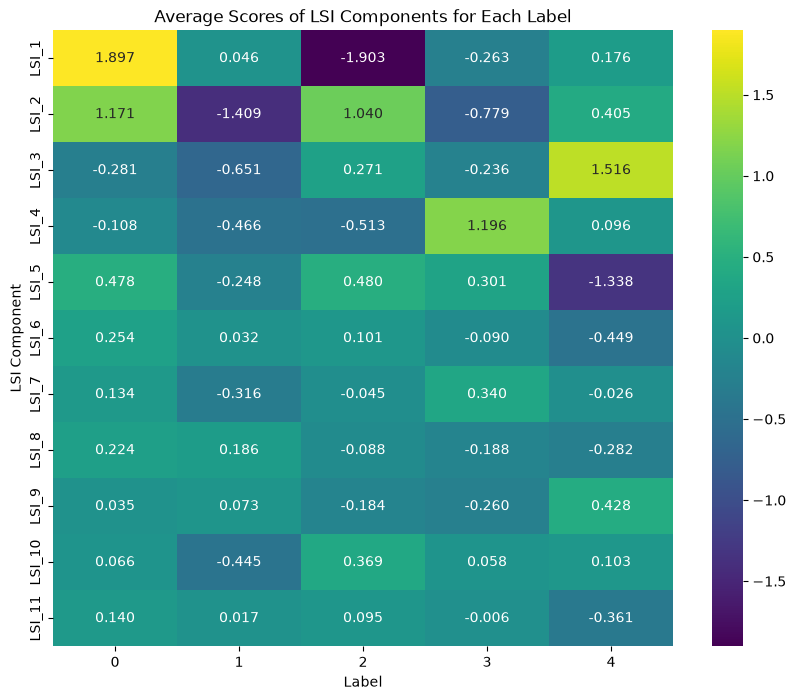

In [94]:
lsi_df['Label'] = df_train['Label']

avg_scores = lsi_df.groupby('Label').mean()

plot_heatmap(avg_scores.T, "Average Scores of LSI Components for Each Label" , (10, 8) ,"Label" ,"LSI Component")

**Proposed method (Q19):** represent each category by the mean latent vector of its training documents (the heatmap above), then classify a document by assigning it to the category whose mean vector has the highest cosine similarity to the documents latent vector.
This needs no manual interpretation of what each component means. it only relies on the geometric structure of the latent space, so it scales to any number of categories.

## Classification

In [95]:
def label_alignment_scores(document_latent_vector, lsi_df):
    label_scores = {}
    for label in lsi_df['Label'].unique():
        label_documents = lsi_df[lsi_df['Label'] == label].drop(columns=['Label'])
        average_latent_vector = label_documents.mean(axis=0)
        similarity_score = cosine_similarity([document_latent_vector], [average_latent_vector])[0][0]
        label_scores[label] = similarity_score
    return label_scores

document_latent_vector = lsi_matrix[1280]
alignment_scores = label_alignment_scores(document_latent_vector, lsi_df)

print('Alignment Scores:')
for label, score in alignment_scores.items():
    print(f'Label {label}: {score}')


Alignment Scores:
Label 0: -0.3325238405886444
Label 1: -0.32415803650616926
Label 2: 0.8288592650509983
Label 3: -0.20518045800216445
Label 4: -0.0642776065437015


In [96]:
predicted_labels = []

for i, document_latent_vector in enumerate(lsi_matrix):
    alignment_scores = label_alignment_scores(document_latent_vector, lsi_df)
    predicted_label = max(alignment_scores, key=alignment_scores.get)
    predicted_labels.append(predicted_label)

predicted_labels = pd.Series(predicted_labels)
accuracy = (predicted_labels == lsi_df['Label']).mean()
print('Training Set Accuracy:', accuracy)


Training Set Accuracy: 0.7765


## Q20

In [ ]:
word_counts_scaled_test = scaler.transform(word_counts_df_test)

lsi_matrix_test = word_counts_scaled_test @ svd.components_.T
lsi_df_test = pd.DataFrame(lsi_matrix_test, columns=[f'LSI_{i+1}' for i in range(n_components)])
lsi_df_test['Label'] = df_test['Label']

test_predicted_labels = []
for doc_vec in lsi_matrix_test:
    scores = label_alignment_scores(doc_vec, lsi_df)
    pred_label = max(scores, key=scores.get)
    test_predicted_labels.append(pred_label)

test_predicted_labels = pd.Series(test_predicted_labels)
test_accuracy = (test_predicted_labels == df_test['Label']).mean()

print('Test Accuracy:', test_accuracy)

Test Accuracy: 0.7911111111111111


In [98]:
CATEGORY_NAMES = {0: 'Politics', 1: 'Sport', 2: 'Technology', 3: 'Entertainment', 4: 'Business'}

print('\nAccuracy by category on the test set:')
for label in sorted(lsi_df['Label'].unique()):
    name = CATEGORY_NAMES.get(label, 'Unknown')
    mask = df_test['Label'] == label
    if mask.sum() > 0:
        class_acc = (test_predicted_labels[mask] == df_test['Label'][mask]).mean()
        print(f"  Category {label} ({name}): {class_acc:.4f}")
    else:
        print(f"  Category {label} ({name}): N/A (no samples in test set)")



Accuracy by category on the test set:
  Category 0 (Politics): N/A (no samples in test set)
  Category 1 (Sport): N/A (no samples in test set)
  Category 2 (Technology): N/A (no samples in test set)
  Category 3 (Entertainment): N/A (no samples in test set)
  Category 4 (Business): 0.7911


> the source dataset is sorted by label, so the literal "last 225 rows" test split (as specified in the assignment) contains only category 4 (Business) documents. Per category accuracy for categories 0-3 is therefore not measurable with this split, and the overall test accuracy above is really a Business only accuracy figure. this is a property of the mandated split, not of the classifier.